# Γιάννης Φίλλης ΑΜ:5380, Κωνσταντίνος Ζώης ΑΜ:5226

## Ερώτηση 3

In [1]:
import pandas as pd
movies = pd.read_csv("movies_metadata.csv",low_memory=False)

In [2]:
movies['id'] = pd.to_numeric(movies['id'], errors='coerce')

In [3]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45466 non-null  object 
 1   belongs_to_collection  4494 non-null   object 
 2   budget                 45466 non-null  object 
 3   genres                 45466 non-null  object 
 4   homepage               7782 non-null   object 
 5   id                     45463 non-null  float64
 6   imdb_id                45449 non-null  object 
 7   original_language      45455 non-null  object 
 8   original_title         45466 non-null  object 
 9   overview               44512 non-null  object 
 10  popularity             45461 non-null  object 
 11  poster_path            45080 non-null  object 
 12  production_companies   45463 non-null  object 
 13  production_countries   45463 non-null  object 
 14  release_date           45379 non-null  object 
 15  re

In [4]:
movies.genres

,genres
0,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '..."
1,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '..."
2,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ..."
3,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam..."
4,"[{'id': 35, 'name': 'Comedy'}]"
...,...
45461,"[{'id': 18, 'name': 'Drama'}, {'id': 10751, 'n..."
45462,"[{'id': 18, 'name': 'Drama'}]"
45463,"[{'id': 28, 'name': 'Action'}, {'id': 18, 'nam..."
45464,[]


In [5]:
import ast
movies['genres'] = movies['genres'].apply(ast.literal_eval)

Θα χρησιμοποιήσουμε την **explode()** για να πάρουμε τα genres και θα πετάξουμε τις ταινίες με null genres.

In [6]:
df_movies = movies.explode('genres')

In [7]:
df_movies = df_movies.dropna(subset=['genres'])

Έπειτα δημιουργούμε μία καινούργια στήλη με όνομα **genres_name**

In [8]:
df_movies['genre_names'] = df_movies['genres'].apply(lambda x: x['name'])

In [9]:
df_movies.info()

<class 'pandas.core.frame.DataFrame'>
Index: 91106 entries, 0 to 45463
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  91106 non-null  object 
 1   belongs_to_collection  11094 non-null  object 
 2   budget                 91106 non-null  object 
 3   genres                 91106 non-null  object 
 4   homepage               16373 non-null  object 
 5   id                     91094 non-null  float64
 6   imdb_id                91076 non-null  object 
 7   original_language      91090 non-null  object 
 8   original_title         91106 non-null  object 
 9   overview               90033 non-null  object 
 10  popularity             91089 non-null  object 
 11  poster_path            90841 non-null  object 
 12  production_companies   91097 non-null  object 
 13  production_countries   91097 non-null  object 
 14  release_date           91048 non-null  object 
 15  revenue

Τώρα αυτό που θα κάνουμε είναι να κρατήσουμε μόνο τις ταινίες που ανήκουν στις 3 κατηγορίες που ζητούνται.

In [10]:
requested_genres = ['War','Music','Animation']
df_movies = df_movies[df_movies['genre_names'].isin(requested_genres)]

In [11]:
df_movies.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4856 entries, 0 to 45449
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  4856 non-null   object 
 1   belongs_to_collection  771 non-null    object 
 2   budget                 4856 non-null   object 
 3   genres                 4856 non-null   object 
 4   homepage               1032 non-null   object 
 5   id                     4856 non-null   float64
 6   imdb_id                4853 non-null   object 
 7   original_language      4852 non-null   object 
 8   original_title         4856 non-null   object 
 9   overview               4818 non-null   object 
 10  popularity             4855 non-null   object 
 11  poster_path            4840 non-null   object 
 12  production_companies   4855 non-null   object 
 13  production_countries   4855 non-null   object 
 14  release_date           4853 non-null   object 
 15  revenue 

Όπως ζητάει η εκφώνηση, θα αφαιρέσουμε τώρα τις ταινίες που ανήκουν σε παραπάνω από ένα genres. Οπότε θα δούμε ποιές ταινίες (ids) εμφανίζονται μία φορά και θα κρατήσουμε αυτές.

In [12]:
id_counts = df_movies['id'].value_counts()
single_ids = id_counts[id_counts == 1].index

df_movies = df_movies[df_movies['id'].isin(single_ids)]

In [13]:
df_movies.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4654 entries, 0 to 45449
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  4654 non-null   object 
 1   belongs_to_collection  731 non-null    object 
 2   budget                 4654 non-null   object 
 3   genres                 4654 non-null   object 
 4   homepage               980 non-null    object 
 5   id                     4654 non-null   float64
 6   imdb_id                4651 non-null   object 
 7   original_language      4650 non-null   object 
 8   original_title         4654 non-null   object 
 9   overview               4618 non-null   object 
 10  popularity             4653 non-null   object 
 11  poster_path            4642 non-null   object 
 12  production_companies   4653 non-null   object 
 13  production_countries   4653 non-null   object 
 14  release_date           4651 non-null   object 
 15  revenue 

In [14]:
df_movies = df_movies.reset_index(drop=True)

In [15]:
total_movies_per_genre = df_movies['genre_names'].value_counts()
print(total_movies_per_genre)

genre_names
Animation    1843
Music        1518
War          1293
Name: count, dtype: int64


Όπως μπορούμε να παρατηρήσουμε παραπάνω, δεν υπάρχει και πολύ μεγάλο **class imbalance**.

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import KFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score
import numpy as np

Γενικά αποφασίσαμε να χρησιμοποιήσουμε το random_state ώστε να μην αλλάζουν τα αποτελέσματα όταν το τρέχουμε. Στον αλγόριθμο **KNN** επιλέξαμε 5 γείτονες να ελέγχει. Στο **Logistic Regression** για ασφάλεια ότι θα κάνει converge ως **max_iter** τα 1000 και στο **SVC** αποφασίσαμε να χρησιμοποιήσουμε τις default τιμές. Στο **MLP** επιλέξαμε ένα σχετικά απλό μοντέλο με ένα κρυμμένο επίπεδο και 5 νευρώνες. Ως **max_iter** θέσαμε 500 διότι αρχικά είχαμε βάλει 100 αλλά έβγαζε μήνυμα πως δεν μπορούσε να κάνει converge.

In [17]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=3),
    "kNN": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(),
    "MLP": MLPClassifier(hidden_layer_sizes=(5,), max_iter=500, random_state=3)
}

### TFIDF

Για τις περιπτώσεις όπου έχουμε null περίληψη τα μετατρέψαμε σε κενό string. Φυσικά αυτό έχει ως αποτέλεσμα να βγαίνει 0 το tfidf.

In [18]:
df_movies['overview'] = df_movies['overview'].fillna('')

In [19]:
X = df_movies['overview'].values
y = df_movies['genre_names'].values

k_fold = KFold(n_splits=5)

results = {model_name: {"accuracy": [], "precision": [], "recall": [], "y_true": [], "y_pred": []} for model_name in models}
for train_idx,test_idx in k_fold.split(X,y):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    vectorizer = TfidfVectorizer(max_features = 5000, stop_words='english')

    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_test_tfidf = vectorizer.transform(X_test)

    for model_name, model in models.items():
        model.fit(X_train_tfidf,y_train)
        y_pred = model.predict(X_test_tfidf)

        model_acc = accuracy_score(y_test, y_pred)
        model_rec = recall_score(y_test, y_pred,average='macro')
        model_prec = precision_score(y_test,y_pred,average='macro')

        results[model_name]['accuracy'].append(model_acc)
        results[model_name]['recall'].append(model_rec)
        results[model_name]['precision'].append(model_prec)
        results[model_name]['y_true'].extend(y_test)
        results[model_name]['y_pred'].extend(y_pred)

final_results = []
for model_name, metrics in results.items():
    final_results.append({
        "Classifier": model_name,
        "Accuracy": np.mean(metrics["accuracy"]),
        "Precision": np.mean(metrics["precision"]),
        "Recall": np.mean(metrics["recall"])
    })

results_df = pd.DataFrame(final_results)

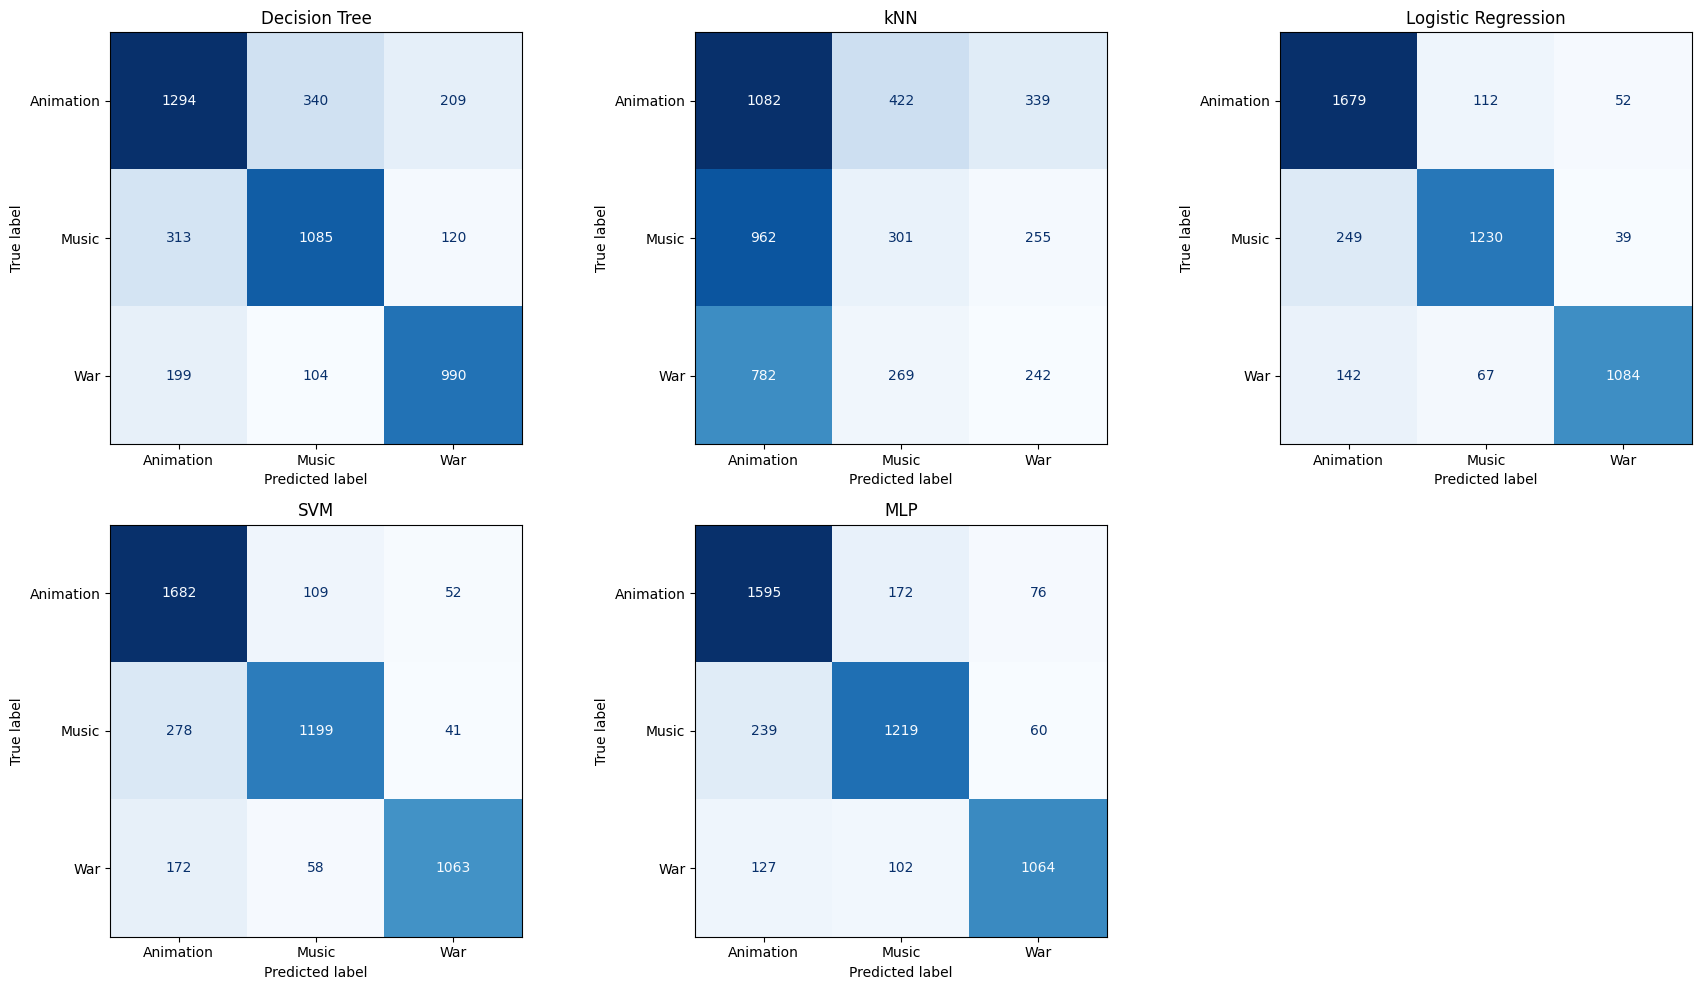

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

model_names = list(results.keys())
labels = np.unique(y)

positions = [(0, 0),(0, 1),(0, 2),(1, 0),(1, 1)]

for (model_name, (i, j)) in zip(model_names, positions):
    y_true = results[model_name]['y_true']
    y_pred = results[model_name]['y_pred']

    conf_matrix = confusion_matrix(y_true, y_pred, labels=labels)

    disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix,display_labels=labels)

    disp.plot(ax=axes[i, j], cmap='Blues', colorbar=False)
    axes[i, j].set_title(model_name)

axes[1, 2].set_visible(False)

plt.tight_layout()
plt.show()

Παρατηρώντας κανείς τα παραπάνω **confusion matrixes** μπορεί να βγάλει πολύ ενδιαφέροντα συμπεράσματα. Βλέπουμε πως όλα τα μοντέλα εκτός το **KNN** έχουν έντονη διαγώνιο, γεγονός που υποδεικνύει πως αυτά τα μοντέλα έχουν και πολύ υψηλή ακρίβεια στις προβλέψεις. Το **KNN** δείχνει έντονη την πρώτη στήλη, δηλαδή προβλέπει να περισσότερα ως Animation. Αυτό υποδηλώνει ότι το μοντέλο παρουσιάζει **bias** προς την πιο συχνή κατηγορία και δείχνει μία δυσκολία να διακρίνει να διακρίνει τις άλλες δύο κατηγορίες.  
Αν ήταν ήταν να βγάλουμε και ένα ακόμα συμπέρασμα, αυτό θα ήταν πως οι λέξεις της κατηγορίας war είναι τελείως διαφορετικές από αυτές της κατηγορίας Music, κάτι που το επιβεβαιώνουν όλα σχεδόν τα μοντέλα (και φυσικά είναι και αναμενόμενο).

Παρακάτω μπορούμε να δούμε αυτό που περιμέναμε και βλέποντας τα **confusion matrixes**. Το **KNN** έχει τις χαμηλότερες τιμές σε όλες τις μετρικές. Αμέσως μετά ακολουθεί το **Decision Tree** και έπειτα με μικρή διαφορά μεταξύ τους, το **MLP**, το **SVM** και το **Logistic Regression** που φαίνεται να έχει τις καλύτερες επιδόσεις.

In [21]:
results_df.head()

,Classifier,Accuracy,Precision,Recall
0,Decision Tree,0.723881,0.717572,0.733560
1,kNN,0.349157,0.339334,0.338102
2,Logistic Regression,0.857972,0.858342,0.856774
3,SVM,0.847444,0.851564,0.847454
4,MLP,0.833260,0.829233,0.833096


Τέλος δοκιμάζουμε την περίληψη που δίνεται για να δούμε πως συμπεριφέρονται οι classifiers.

In [22]:
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_tfidf = vectorizer.fit_transform(X)

for model_name, model in models.items():
    model.fit(X_tfidf, y)

In [23]:
test_overview = ["A lonely soldier plays the piano while waiting for the battle to begin"]

test_tfidf = vectorizer.transform(test_overview)

for model_name, model in models.items():
    prediction = model.predict(test_tfidf)
    print(f"{model_name}: {prediction}")

Decision Tree: ['War']
kNN: ['Animation']
Logistic Regression: ['War']
SVM: ['War']
MLP: ['War']


Βλέπουμε πως όλα τα μοντέλα έχουν προβλέψει σωστά το είδος War εκτός του kNN, που η πρόβλεψή του δεν είναι καθόλου σχετική όπως περιμέναμε, αφού το kNN κατηγοριοποιεί τα περισσότερα κείμενα ως Animation και έχει τις χαμηλότερες μετρικές.  

### Word2Vec

Τώρα θα χρησιμοποιήσουμε το **word2vec**.

Αν δουλεύουμε σε collab πρέπει να κάνουμε install την βιβλιοθήκη gensim κάθε φορά.

In [25]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 65.8 MB/s eta 0:00:00


In [26]:
import gensim.downloader as api
import gensim
path = api.load("glove-wiki-gigaword-50", return_path=True)
g_model = gensim.models.KeyedVectors.load_word2vec_format(path)

[==================================================] 100.0% 66.0/66.0MB downloaded


Με την παρακάτω συνάρτηση **prepare_vectors** αυτό που κάνουμε είναι να παίρνουμε την κάθε περίπτωση και να την κάνουμε tokenize (δηλαδή να σπάει σε tokens) και μετά όλα αυτά τα tokens τα βάζουμε σε ένα array. Φυσικά στην περίπτωση όπου είναι κενή η περίληψη απλά βάζουμε το μηδενικό διάνυσμα.

In [27]:
import numpy as np
import nltk
def prepare_vectors(text, model):
    tokens = nltk.word_tokenize(str(text).lower())
    vecs = [model[word] for word in tokens if word in model]
    if len(vecs) > 0:
        return np.mean(vecs, axis=0)
    else:
        return np.zeros(model.vector_size)

Σε collab πρέπει να κάνουμε κάθε φορά download το πακέτο punkt_tab για να δουλέψει το tokenize.

In [29]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [30]:
X_vec = np.array([prepare_vectors(doc, g_model) for doc in df_movies['overview'].values])
y = df_movies['genre_names'].values

In [31]:
y = df_movies['genre_names'].values

k_fold = KFold(n_splits=5)


results_w2v = {model_name: {"accuracy": [], "precision": [], "recall": [],"y_true": [], "y_pred": []} for model_name in models}
for train_idx,test_idx in k_fold.split(X_vec,y):
    X_train, X_test = X_vec[train_idx], X_vec[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    for model_name, model in models.items():
        model.fit(X_train,y_train)
        y_pred = model.predict(X_test)#,y_train)

        model_acc = accuracy_score(y_test, y_pred)
        model_rec = recall_score(y_test, y_pred,average='macro')
        model_prec = precision_score(y_test,y_pred,average='macro')

        results_w2v[model_name]['accuracy'].append(model_acc)
        results_w2v[model_name]['recall'].append(model_rec)
        results_w2v[model_name]['precision'].append(model_prec)
        results_w2v[model_name]['y_true'].extend(y_test)
        results_w2v[model_name]['y_pred'].extend(y_pred)

final_results_w2v = []
for model_name, metrics in results_w2v.items():
    final_results_w2v.append({
        "Classifier": model_name,
        "Accuracy": np.mean(metrics["accuracy"]),
        "Precision": np.mean(metrics["precision"]),
        "Recall": np.mean(metrics["recall"])
    })

results_w2v_df = pd.DataFrame(final_results_w2v)

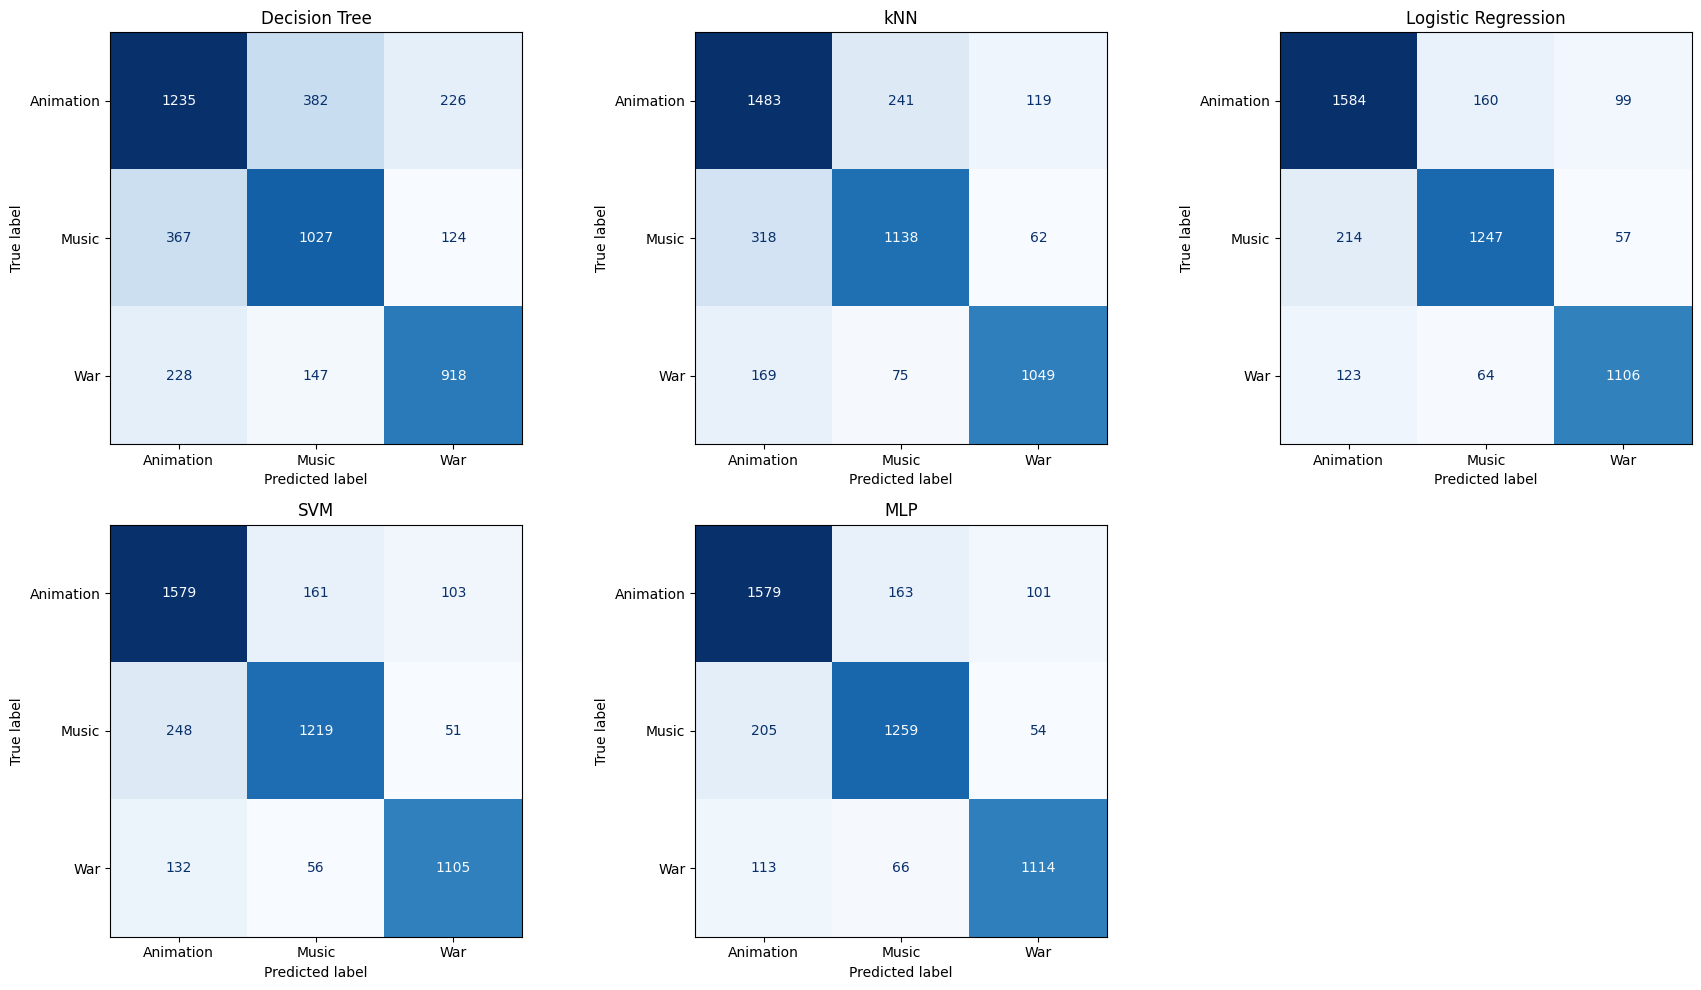

In [32]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

model_names = list(results_w2v.keys())
labels = np.unique(y)

positions = [(0, 0),(0, 1),(0, 2),(1, 0),(1, 1)]

for (model_name, (i, j)) in zip(model_names, positions):
    y_true = results_w2v[model_name]['y_true']
    y_pred = results_w2v[model_name]['y_pred']

    conf_matrix = confusion_matrix(y_true, y_pred, labels=labels)

    disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix,display_labels=labels)

    disp.plot(ax=axes[i, j], cmap='Blues', colorbar=False)
    axes[i, j].set_title(model_name)

axes[1, 2].set_visible(False)

plt.tight_layout()
plt.show()

Με το **word2vec** που χρησιμοποιήσαμε βλέπουμε κάποιες αλλαγές. Πλέον και το **KNN** παρουσιάζει έντονη διαγώνιο, γεγονός που υποδεικνύει πως πλέον και αυτό κάνει αρκετά σωστές προβλέψεις. Και τα υπόλοιπα μοντέλα συνεχίζουν να έχουν έντονη διαγώνιο.

Παρακάτω, παρατηρούμε όπως είδαμε και από το **confusion matrix** πως ο **ΚΝΝ** πλεόν έχει υψηλότερες τιμές στις μετρικές του και προβλέπει πολύ καλύτερα. Τα **Logistic Regression**, **SVM** και **MLP** φαίνεται να έχουν ακόμα τις ίδιες περίπου επιδόσεις, ωστόσο το **Decision Tree** φαίνεται να έχει μία πτώση σε σχέση με το **TFIDF**.

In [33]:
results_w2v_df

,Classifier,Accuracy,Precision,Recall
0,Decision Tree,0.683279,0.678716,0.691979
1,kNN,0.788565,0.784962,0.794104
2,Logistic Regression,0.845935,0.837750,0.846952
3,SVM,0.838630,0.831997,0.839839
4,MLP,0.849157,0.840468,0.849807


Δοκιμάζουμε και εδώ την περίληψη που δίνεται.

In [34]:
test_overview = "A lonely soldier plays the piano while waiting for the battle to begin"

test_vec = prepare_vectors(test_overview, g_model)
test_vec = test_vec.reshape(1, -1)  # shape (1, 50)

for model_name, model in models.items():
    model.fit(X_vec, y)

In [35]:
for model_name, model in models.items():
    pred = model.predict(test_vec)
    print(f"{model_name}: {pred}")

Decision Tree: ['Music']
kNN: ['War']
Logistic Regression: ['War']
SVM: ['War']
MLP: ['War']


Όλα τα μοντέλα προβλέπουν το War εκτός του Decision Tree που προβλέπει Music. Και αυτή η πρόβλεψη δεν είναι τελείως λάθος καθώς το κείμενο έχει και στοιχεία από το Music genre, αλλά στον classifier δεν κατάφερε να υπερισχύσει το War.  

## BONUS

In [36]:
df_movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4654 entries, 0 to 4653
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  4654 non-null   object 
 1   belongs_to_collection  731 non-null    object 
 2   budget                 4654 non-null   object 
 3   genres                 4654 non-null   object 
 4   homepage               980 non-null    object 
 5   id                     4654 non-null   float64
 6   imdb_id                4651 non-null   object 
 7   original_language      4650 non-null   object 
 8   original_title         4654 non-null   object 
 9   overview               4654 non-null   object 
 10  popularity             4653 non-null   object 
 11  poster_path            4642 non-null   object 
 12  production_companies   4653 non-null   object 
 13  production_countries   4653 non-null   object 
 14  release_date           4651 non-null   object 
 15  reve

Όπως μπορούμε να δούμε έχουμε μία πληθώρα από features. Εμείς επιλέξαμε να χρησιμοποιήσουμε και να αναλύσουμε,, εκτός από το overview, και τα **budget**,**revenue**,**runtime**,**vote_average**.

In [37]:
df_bonus = df_movies[['id','budget','revenue','runtime','vote_average','vote_count','overview','genre_names']].copy()

In [38]:
df_bonus = df_bonus.reset_index(drop=True)

In [39]:
df_bonus.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4654 entries, 0 to 4653
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            4654 non-null   float64
 1   budget        4654 non-null   object 
 2   revenue       4653 non-null   float64
 3   runtime       4647 non-null   float64
 4   vote_average  4653 non-null   float64
 5   vote_count    4653 non-null   float64
 6   overview      4654 non-null   object 
 7   genre_names   4654 non-null   object 
dtypes: float64(5), object(3)
memory usage: 291.0+ KB


Βλέπουμε πως κάποιες τιμές δεν είναι αριθμητικές, ενώ θα έπρεπε, οπότε το πρώτο που θα κάνουμε είναι να τα διορθώσουμε.

In [40]:
df_bonus['budget'] = pd.to_numeric(df_bonus['budget'],errors='coerce')

In [41]:
df_bonus.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4654 entries, 0 to 4653
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            4654 non-null   float64
 1   budget        4654 non-null   int64  
 2   revenue       4653 non-null   float64
 3   runtime       4647 non-null   float64
 4   vote_average  4653 non-null   float64
 5   vote_count    4653 non-null   float64
 6   overview      4654 non-null   object 
 7   genre_names   4654 non-null   object 
dtypes: float64(5), int64(1), object(2)
memory usage: 291.0+ KB


In [42]:
revenue_stats = df_bonus.groupby('genre_names')['revenue'].mean()
runtime_stats = df_bonus.groupby('genre_names')['runtime'].mean()
vote_average_stats = df_bonus.groupby('genre_names')['vote_average'].mean()
vote_count_stats = df_bonus.groupby('genre_names')['vote_count'].mean()

In [43]:
revenue_stats.head()

,revenue
genre_names,
Animation,3.483825e+07
Music,6.692751e+06
War,1.225197e+07


In [44]:
runtime_stats.head()

,runtime
genre_names,
Animation,63.760740
Music,100.380356
War,112.785438


In [45]:
vote_average_stats.head()

,vote_average
genre_names,
Animation,6.295277
Music,5.887154
War,6.034184


In [46]:
vote_count_stats.head()

,vote_count
genre_names,
Animation,235.137894
Music,59.416996
War,121.629544


Στα πεδία **revenue**,**runtime**, **vote_count** και **vote_average** παρατηρούμε πως υπάρχουν κάποιες null τιμές. Οπότε επιλέξαμε να τις αντικαταστήσουμε με τον μέσο όρο. Από τα παραπάνω μπορούμε να δούμε πως στο revenue η κάθε κατηγορία ταινίας έχει μεγάλη διαφορά, στο runtime οι ταινίες με θέμα Music και War δεν φαίνεται να έχουν και πολύ μεγάλη διαφορά, ωστόσο τα Animations φαίνεται να έχουν πολύ μικρότερη διάρκεια.  
Τέλος τα vote_averages δεν φαίνεται να διαφέρουν και ιδιαίτερα.  
Εμείς επιλέξαμε να βάλουμε στις τιμές που λείπουν τον μέσο όρο της κατηγορίας της ταινίας και όχι τον γενικό μέσο όρο, το οποίο βέβαια στα δύο τελευταία ίσως να μην έχει και τόσο διαφορά, έχει όμως στο πρώτο.

Οπότε, όπως μάθαμε θα χρησιμοποιήσουμε το παρακάτω loop, το οποίο ελέγχει αν το αντίστοιχο feature είναι null και αν ισχύει αυτό τότε αντικαθιστά την τιμή αυτή με τον μέσο όρο του genre στο οποίο ανήκει.

In [47]:
for idx,row in df_bonus.iterrows():
    if pd.isna(row['revenue']):
        genre_value = row['genre_names']
        df_bonus.loc[idx,'revenue'] = revenue_stats[genre_value]
    if pd.isna(row['runtime']):
        genre_value = row['genre_names']
        df_bonus.loc[idx,'runtime'] = runtime_stats[genre_value]
    if pd.isna(row['vote_average']):
        genre_value = row['genre_names']
        df_bonus.loc[idx,'vote_average'] = vote_average_stats[genre_value]
    if pd.isna(row['vote_count']):
        genre_value = row['genre_names']
        df_bonus.loc[idx,'vote_count'] = vote_count_stats[genre_value]

Όπως μπορούμε να δούμε τα δεδομένα μας πλέον είναι καθαρά. Οπότε μπορούμε να προχωρήσουμε παρακάτω στην ανάλυσή μας στα έξτρα features.

In [48]:
df_bonus.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4654 entries, 0 to 4653
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            4654 non-null   float64
 1   budget        4654 non-null   int64  
 2   revenue       4654 non-null   float64
 3   runtime       4654 non-null   float64
 4   vote_average  4654 non-null   float64
 5   vote_count    4654 non-null   float64
 6   overview      4654 non-null   object 
 7   genre_names   4654 non-null   object 
dtypes: float64(5), int64(1), object(2)
memory usage: 291.0+ KB


In [49]:
df_bonus[['budget','revenue','runtime','vote_average','vote_count']].describe()

,budget,revenue,runtime,vote_average,vote_count
count,4.654000e+03,4.654000e+03,4654.000000,4654.000000,4654.000000
mean,6.517799e+06,1.938296e+07,89.325310,6.089621,146.287309
std,2.310318e+07,8.889549e+07,45.862826,1.706111,548.851317
min,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000
25%,0.000000e+00,0.000000e+00,75.000000,5.600000,4.000000
50%,0.000000e+00,0.000000e+00,92.000000,6.400000,12.000000
75%,0.000000e+00,0.000000e+00,108.000000,7.100000,50.000000
max,2.600000e+08,1.274219e+09,874.000000,10.000000,7048.000000


Όπως βλέπουμε παραπάνω, δυστυχώς κάποια features έχουν και μηδενικές τιμές, το οποίο προφανώς δεν μπορεί να ισχύει και πιθανόν είναι λόγο του ότι δεν ήταν η συγκεκριμένη πληροφορία διαθέσιμη.  
Αρχικά χρησιμοποιήσαμε την mutual_info_classif της βιβλιοθήκης sklearn προκειμένου να δούμε πόση πληροφορία παίρνουμε από τα features μας για την κατηγορία ταινίας μας. Παρακάτω τα αποτελέσματα παρουσιάζονται σε φθίνουσα σειρά και βλέπουμε ότι το runtime είναι αρκετά ισχυρό feature.

In [50]:
from sklearn.feature_selection import mutual_info_classif

X = df_bonus[['budget','revenue','runtime','vote_average','vote_count']]
y = df_bonus['genre_names']

mi = mutual_info_classif(X, y)
pd.Series(mi, index=X.columns).sort_values(ascending=False)


,0
runtime,0.208335
vote_count,0.051256
budget,0.038953
revenue,0.014662
vote_average,0.004975


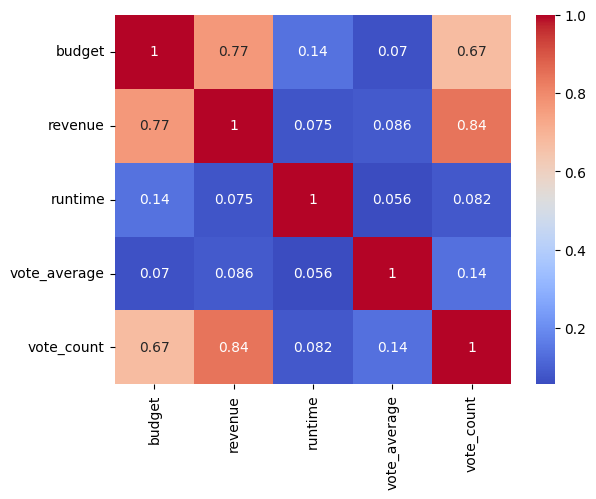

In [51]:
import seaborn as sns

corr = df_bonus[['budget','revenue','runtime','vote_average','vote_count']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

Από τον παραπάνω πίνακα μπορούμε να βγάλουμε πολύ χρήσιμα συμπεράσματα. Βλέπουμε πως το **vote_count** έχει μία συσχέτιση τόσο με το **revenue** όσο και με το **budget**. Το **revenue** έχει επίσης συσχέτιση και με το **budget** και με το **vote_count**. Ομοίως το **budget** συσχετίζεται και με το **vote_count**.  
Λαμβάνοντας υπόψιν το **correlation matrix** καθώς και τα αποτελέσματα απο την **mutual_info** αποφασίσαμε να χρησιμοποιήσουμε ως έξτρα features το **runtime** και το **vote_count**. Οι λόγοι είναι αρχικά ότι είναι τα δύο πιο "χρήσιμα" features (με βάση το mutual_info) αλλά και το vote_count έχει υψηλή συσχέτιση με τα υπόλοιπα τα οποία έτσι και αλλιώς δεν δίνουν και πολύ πληροφορία. Το vote_average είναι μεν ανεξάρτητο από όλα τα υπόλοιπα αλλά φαίνεται να μας δίνει και την λιγότερη πληροφορία.

Όπως είδαμε πιο πάνω οι κλίμακες των 2 features που θα χρησιμοποιήσουμε την **standard scaler** για να κανονικοποιήσουμε τα δεδομένα.

### TFIDF

In [52]:
df_bonus['overview'] = df_bonus['overview'].fillna('')

In [53]:
from scipy.sparse import hstack
from sklearn.preprocessing import StandardScaler
import numpy as np

numeric_features = ['runtime', 'vote_count']
X = df_bonus['overview'].values
y = df_bonus['genre_names'].values

k_fold = KFold(n_splits=5)


results_bonus = {model_name: {"accuracy": [], "precision": [], "recall": [], "y_true": [], "y_pred": []} for model_name in models}
for train_idx,test_idx in k_fold.split(X,y):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    vectorizer = TfidfVectorizer(max_features = 5000, stop_words='english')
    scaler = StandardScaler()

    X_numeric = scaler.fit_transform(df_bonus[numeric_features].iloc[train_idx])
    X_numeric_test = scaler.transform(df_bonus[numeric_features].iloc[test_idx])

    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_test_tfidf = vectorizer.transform(X_test)

    X_train_final = hstack([X_train_tfidf, X_numeric,])
    X_test_final  = hstack([X_test_tfidf, X_numeric_test,])

    for model_name, model in models.items():
        model.fit(X_train_final,y_train)
        y_pred = model.predict(X_test_final)

        model_acc = accuracy_score(y_test, y_pred)
        model_rec = recall_score(y_test, y_pred,average='macro')
        model_prec = precision_score(y_test,y_pred,average='macro')

        results_bonus[model_name]['accuracy'].append(model_acc)
        results_bonus[model_name]['recall'].append(model_rec)
        results_bonus[model_name]['precision'].append(model_prec)
        results_bonus[model_name]['y_true'].extend(y_test)
        results_bonus[model_name]['y_pred'].extend(y_pred)

final_results_bonus = []
for model_name, metrics in results_bonus.items():
    final_results_bonus.append({
        "Classifier": model_name,
        "Accuracy": np.mean(metrics["accuracy"]),
        "Precision": np.mean(metrics["precision"]),
        "Recall": np.mean(metrics["recall"])
    })

results_bonus_df = pd.DataFrame(final_results_bonus)

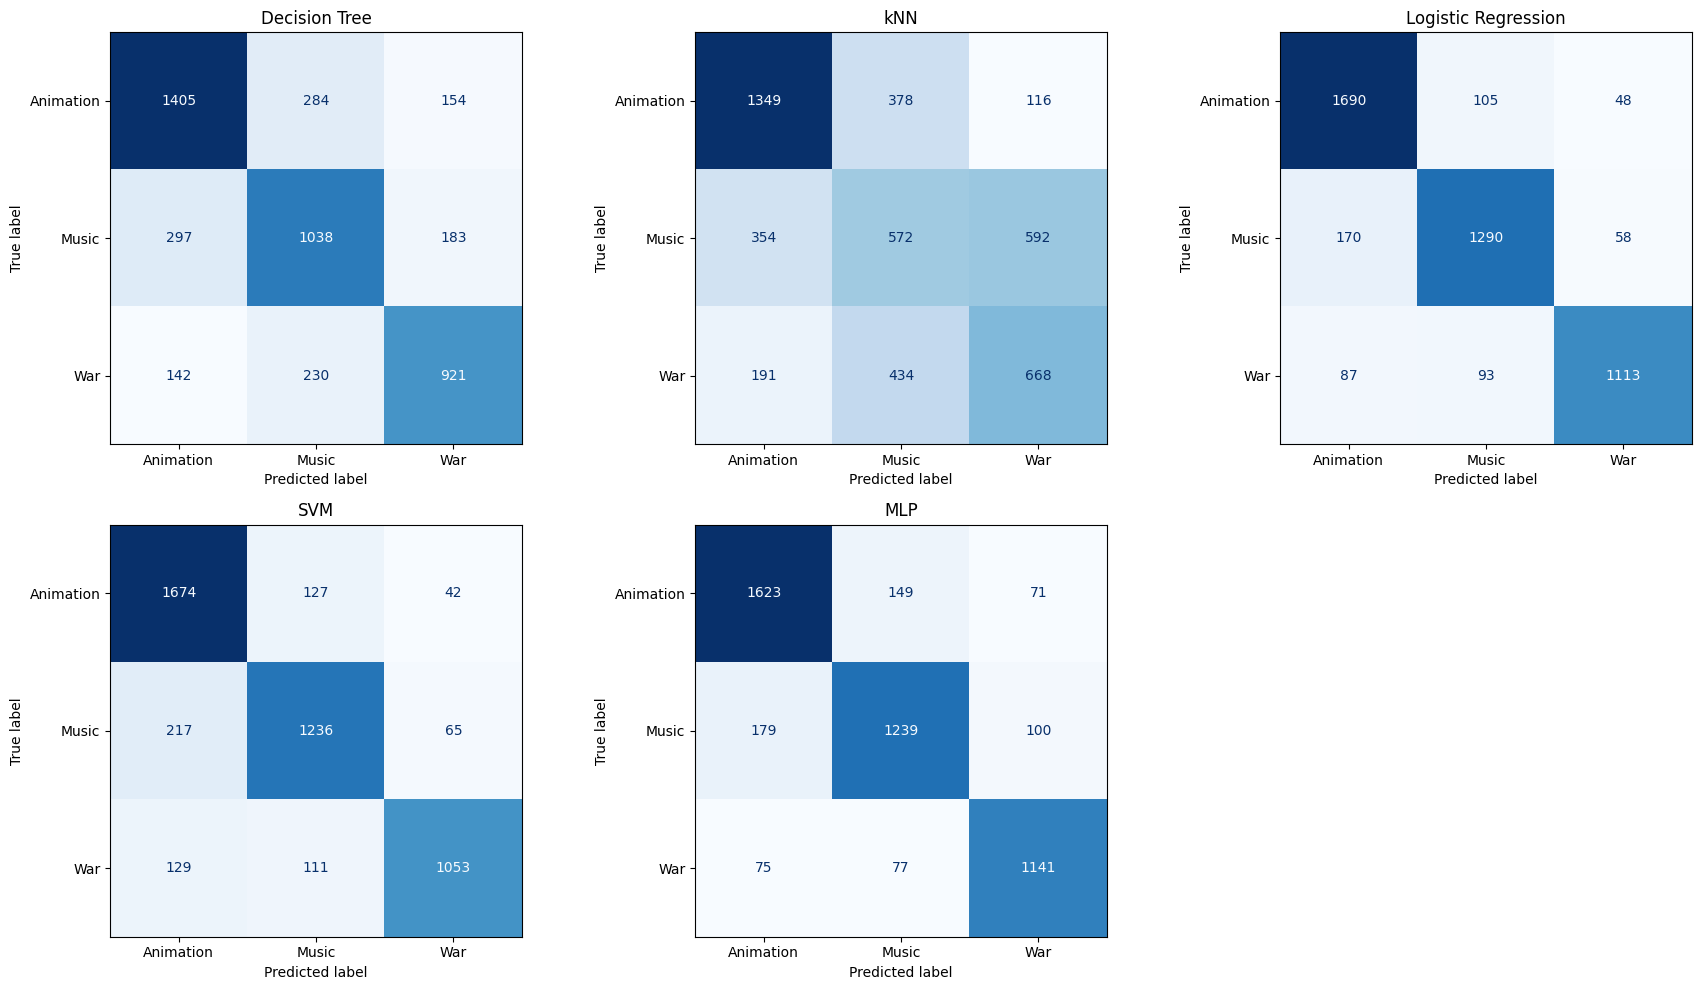

In [54]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

model_names = list(results_bonus.keys())
labels = np.unique(y)

positions = [(0, 0),(0, 1),(0, 2),(1, 0),(1, 1)]

for (model_name, (i, j)) in zip(model_names, positions):
    y_true = results_bonus[model_name]['y_true']
    y_pred = results_bonus[model_name]['y_pred']

    conf_matrix = confusion_matrix(y_true, y_pred, labels=labels)

    disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix,display_labels=labels)

    disp.plot(ax=axes[i, j], cmap='Blues', colorbar=False)
    axes[i, j].set_title(model_name)

axes[1, 2].set_visible(False)

plt.tight_layout()
plt.show()

In [55]:
results_df.head()

,Classifier,Accuracy,Precision,Recall
0,Decision Tree,0.723881,0.717572,0.733560
1,kNN,0.349157,0.339334,0.338102
2,Logistic Regression,0.857972,0.858342,0.856774
3,SVM,0.847444,0.851564,0.847454
4,MLP,0.833260,0.829233,0.833096


In [56]:
results_bonus_df

,Classifier,Accuracy,Precision,Recall
0,Decision Tree,0.722811,0.711038,0.723010
1,kNN,0.556309,0.533600,0.532791
2,Logistic Regression,0.879452,0.875972,0.873300
3,SVM,0.851521,0.849840,0.843114
4,MLP,0.860117,0.851178,0.859831


Παραπάνω, μπορούμε να δούμε πως υπάρχει μία βελτίωση. Την μεγαλύτερη βελτίωση την έχει το kNN το οποίο και στις τρεις μετρικές αυξήθηκε ραγδαία. Το MLP και αυτό είδε μία μικρή βελτίωση καθώς και το Logistic Regression. Αντίθετα, το svm έχει μία μικρή μείωση στο Precision και ελάχιστα στο Recall, όπως και το Decision Tree αλλά σίγουρα όχι πολύ μεγάλη.

### Word2vec

In [57]:
X_vec = np.array([prepare_vectors(doc, g_model) for doc in df_bonus['overview'].values])
y = df_bonus['genre_names'].values

In [58]:
y = df_bonus['genre_names'].values
numeric_features = ['runtime','vote_count']

k_fold = KFold(n_splits=5)


results_bonus_w2v = {model_name: {"accuracy": [], "precision": [], "recall": [],"y_true": [], "y_pred": []} for model_name in models}
for train_idx,test_idx in k_fold.split(X_vec,y):
    X_train, X_test = X_vec[train_idx], X_vec[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    for model_name, model in models.items():
        scaler = StandardScaler()

        X_numeric = scaler.fit_transform(df_bonus[numeric_features].iloc[train_idx])
        X_numeric_test = scaler.transform(df_bonus[numeric_features].iloc[test_idx])

        X_train_final = np.hstack([X_train, X_numeric])
        X_test_final  = np.hstack([X_test, X_numeric_test])
        model.fit(X_train_final,y_train)
        y_pred = model.predict(X_test_final)#,y_train)

        model_acc = accuracy_score(y_test, y_pred)
        model_rec = recall_score(y_test, y_pred,average='macro')
        model_prec = precision_score(y_test,y_pred,average='macro')

        results_bonus_w2v[model_name]['accuracy'].append(model_acc)
        results_bonus_w2v[model_name]['recall'].append(model_rec)
        results_bonus_w2v[model_name]['precision'].append(model_prec)
        results_bonus_w2v[model_name]['y_true'].extend(y_test)
        results_bonus_w2v[model_name]['y_pred'].extend(y_pred)

final_results_bonus_w2v = []
for model_name, metrics in results_bonus_w2v.items():
    final_results_bonus_w2v.append({
        "Classifier": model_name,
        "Accuracy": np.mean(metrics["accuracy"]),
        "Precision": np.mean(metrics["precision"]),
        "Recall": np.mean(metrics["recall"])
    })

results_bonus_w2v_df = pd.DataFrame(final_results_bonus_w2v)

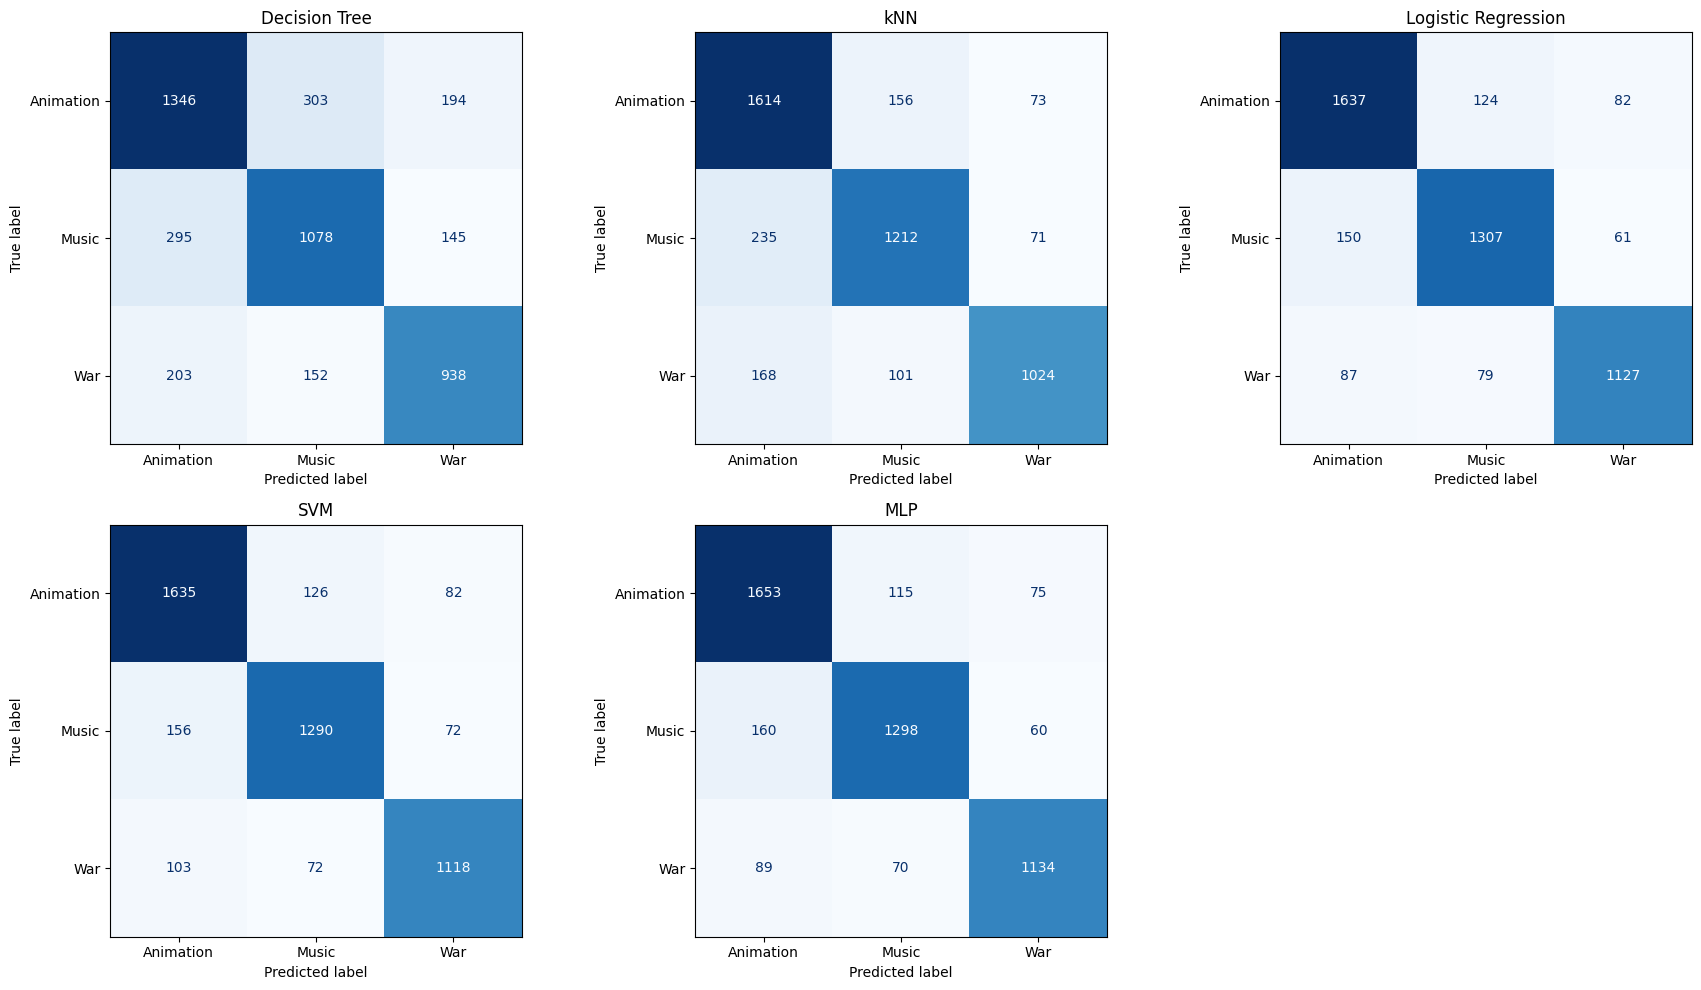

In [59]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

model_names = list(results_bonus_w2v.keys())
labels = np.unique(y)

positions = [(0, 0),(0, 1),(0, 2),(1, 0),(1, 1)]

for (model_name, (i, j)) in zip(model_names, positions):
    y_true = results_bonus_w2v[model_name]['y_true']
    y_pred = results_bonus_w2v[model_name]['y_pred']

    conf_matrix = confusion_matrix(y_true, y_pred, labels=labels)

    disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix,display_labels=labels)

    disp.plot(ax=axes[i, j], cmap='Blues', colorbar=False)
    axes[i, j].set_title(model_name)

axes[1, 2].set_visible(False)

plt.tight_layout()
plt.show()

In [60]:
results_w2v_df.head()

,Classifier,Accuracy,Precision,Recall
0,Decision Tree,0.683279,0.678716,0.691979
1,kNN,0.788565,0.784962,0.794104
2,Logistic Regression,0.845935,0.837750,0.846952
3,SVM,0.838630,0.831997,0.839839
4,MLP,0.849157,0.840468,0.849807


In [61]:
results_bonus_w2v_df.head()

,Classifier,Accuracy,Precision,Recall
0,Decision Tree,0.722384,0.711650,0.726825
1,kNN,0.827243,0.823227,0.822135
2,Logistic Regression,0.874728,0.867081,0.869569
3,SVM,0.868711,0.861474,0.864878
4,MLP,0.877736,0.871264,0.872756


Παρόμοια και εδώ βλέπουμε μία σχετικά σημαντική βελτίωση σε όλες τις μετρικές των μοντέλων.